In [ ]:
import os
WEIGHTS_PATH = 'food11_resnet50_weights.weights.h5'

if not os.path.exists(WEIGHTS_PATH):
    print("Upload your saved weights file:")
    from google.colab import files
    uploaded = files.upload()  # manually select the .h5 file

Upload your saved weights file:


Saving food11_resnet50.weights (2).h5 to food11_resnet50.weights (2).h5


## Custom Training Data:
source: https://www.kaggle.com/datasets/trolukovich/food11-image-dataset <br>
Contains:
*   11 food categories
*   ~16,000 images


In [ ]:
import kagglehub
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.imagenet_utils import preprocess_input

# Load training data from Kaggle
path = kagglehub.dataset_download("trolukovich/food11-image-dataset")
data_path = path + '/training'

data_dir_list = sorted(os.listdir(data_path)) # gathers the folders/classes in the dataset, and prepares them to be processed
names = sorted(os.listdir(data_path)) # stores the sorted class names into a sorted list, so we can access it easily later
nums_of_classes = len(names) # declares a variable with the amount of classes found.
print(f"Found {nums_of_classes} classes: {names}")

# Data generators
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Splitting the dataset
train_gen = datagen.flow_from_directory(
    path+'/training',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_gen = datagen.flow_from_directory(
     path+'/validation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_gen = datagen.flow_from_directory(
     path+'/evaluation',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Using Colab cache for faster access to the 'food11-image-dataset' dataset.
Found 11 classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.


  Loading ResNet50 Model

In [ ]:
import numpy as np
from tensorflow.keras.applications import ResNet50
from keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import preprocess_input, decode_predictions

model = ResNet50(include_top=False, weights='imagenet')
model.trainable = False  # Freezes all layers in the ResNet50 base
model.layers[-1].get_config()   # Gets and obtains the config of the last layer

{'name': 'conv5_block3_out',
 'trainable': False,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'activation': 'relu'}

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

# Add new layers on top of frozen ResNet50
x = model.output
x = GlobalAveragePooling2D()(x) # flattens (7,7,2048) → (2048,)
output = Dense(nums_of_classes, activation='softmax')(x)

# Build final model
final_model = Model(inputs=model.input, outputs=output)
final_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, None,      │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, None,      │      9,472 │ conv1_pad[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, None,      │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, None,      │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, None,      │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, None,      │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, None,      │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, None,      │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, None,      │          0 │ conv2_block1_1_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, None,      │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, None,      │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, None,      │          0 │ conv2_block1_2_b… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, None,      │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, None,      │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, None,      │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, None,      │      1,024 │ conv2_block1_3_c

 Total params: 23,610,251 (90.07 MB)

 Trainable params: 22,539 (88.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
WEIGHTS_PATH = 'food11_resnet50.weights.h5'
# Load weights if they already exist (skip retraining)
if os.path.exists(WEIGHTS_PATH):
    print("Weights found! Loading saved weights...")
    final_model.load_weights(WEIGHTS_PATH)
    history = None  # no history since we skipped training
else:
    print("No saved weights found. Training from scratch...")
    history = final_model.fit(
        train_gen,
        epochs=10,
        validation_data=val_gen
    )
    # Save weights after training
    final_model.save_weights(WEIGHTS_PATH)
    print(f"Weights saved to {WEIGHTS_PATH}")

Weights found! Loading saved weights...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# IMPORTANT: Run this after training !!!!!
from google.colab import files

files.download(WEIGHTS_PATH)
print(f"Downloading {WEIGHTS_PATH}!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



# End of Part 1

Start of Part 2

In [ ]:
# 1. Unfreezing for specialization
base_model = model # ResNet50 backbone we created in the previous cell
base_model.trainable = True # Unfreeze the base model

n_unfreeze = 15 # sets 15 layers to keep as trainable on top of the network

# simple for loop to iteratively unfreeze each layer
for layer in base_model.layers[:-n_unfreeze]:
  layer.trainable = False

# Sanity check
print("Total layers:", len(base_model.layers))
trainable_count = np.sum([int(l.trainable) for l in base_model.layers])
print("Trainable layers in backbone:", trainable_count)

In [ ]:
# 2. Cosine decay learning rate schedule
import tensorflow as tf

# the actual Cosine decay LR schedule
initial_lr_backbone = 1e-5 # 0.00001 very small learning rate for the backbone
initial_lr_head = 1e-3 # 0.001 we shift to a larger learning rate for a new head (automatically)
total_epochs_fine = 10
steps_per_epoch = len(train_gen)
total_steps = total_epochs_fine
steps_per_epoch

cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr_head,
    decay_steps=total_steps,
    alpha=0.1  # final learning rate is = 0.1 * initial
)

# all of the code below gives us a smooth decaying learning rate across the fine-tuning epochs.

In [ ]:
# 3. Differential Learning Rate via elarning-rate multipliers

# Identify backbone vs head layers
backbone_layers = base_model.layers
head_layers = [final_model.layers[-1]] # our Dense classification layer

# Create per-layer learning rate multiplier as dictionary
lr_multipliers = {} # initializae dictionary
# for loop to append multipliers in lr_multipliers
for layer in backbone_layers:
  lr_multipliers[layer.name] = initial_lr_backbone / initial_lr_head # 0.00001 / 0.00 equals to 0.01
# for loop to keep full learning rate for the head
for layer in head_layers:
  lr_multipliers[layer.name] = 1.0

class LrMultAdam(tf.keras.optimizers.Adam):
  def __init__(self, lr_multipliers, **kwargs):
    super().__init__(**kwargs)
    self.lr_multipliers = lr_multipliers

  def _resource_apply_dense(self, grad, var, apply_state=None):
    layer_name = var.name.split('/')[0]
    mult = self.lr_multipliers.get(layer_name, 1.0)
    grad = grad * mult
    return super()._resource_apply_dense(grad, var, apply_state)

# This keeps the head effectively at cosine Learning Rate and the backbone at about 0.000010 on average

In [ ]:
# Compile

optimizer_fine = LrMultAdam(
    lr_multipliers=lr_multipliers,
    learning_rate=cosine_lr
)

final_model.compile(
    optimizer=optimizer_fine,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 4. Optional warm restarts

class WarmRestartCallback(tf.keras.callbacks.Callback):
  def __init__(self, optimizer, restart_steps):
    super().__init__()
    self.optimizer = optimizer
    self.restart_steps = restart_steps
    self.step = 0

  def on_train_batch_end(self, batch, logs=None):
    self.step += 1
    if self.step % self.restart_steps == 0: # Resets the internal iteration count so cosine restarts from
                                            # the top
      self.optimizer.iterations.assign(0)

restart_steps = 3 * steps_per_epoch # restarts every 3 epochs
warm_restart_cb = WarmRestartCallback(optimizer_fine, restart_steps)



In [ ]:
# Final fine-tuning run
history_fine = final_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=total_epochs_fine,
    callbacks=[warm_restart_cb],
)

Epoch 1/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 203s 467ms/step - accuracy: 0.7984 - loss: 0.7145 - val_accuracy: 0.8589 - val_loss: 0.4511
Epoch 2/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 110s 355ms/step - accuracy: 0.9604 - loss: 0.1377 - val_accuracy: 0.8367 - val_loss: 0.5577
Epoch 3/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 110s 355ms/step - accuracy: 0.9819 - loss: 0.0601 - val_accuracy: 0.8586 - val_loss: 0.5400
Epoch 4/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 110s 355ms/step - accuracy: 0.9940 - loss: 0.0260 - val_accuracy: 0.8819 - val_loss: 0.4391
Epoch 5/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 108s 350ms/step - accuracy: 0.9965 - loss: 0.0157 - val_accuracy: 0.8784 - val_loss: 0.4613
Epoch 6/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 107s 345ms/step - accuracy: 0.9947 - loss: 0.0202 - val_accuracy: 0.8169 - val_loss: 0.8516
Epoch 7/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 107s 346ms/step - accuracy: 0.9935 - loss: 0.0219 - val_accuracy: 0.8819 - val_loss: 0.4747
Epoch 8/10
309/309 ━━━━━━━━━━━━━━━━━━━━ 107s 345ms/step - accuracy: 0.9983 -

# End of Part 2

Part 3

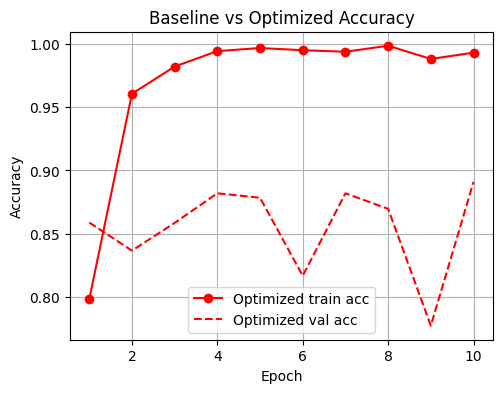

In [ ]:
# 1. Plot baseline vs optimized
import matplotlib.pyplot as plt

# Helper to safely get history dictionaries (incase we have loaded the weights)
hist_base = history.history if history is not None else None
hist_opt = history_fine.history if history_fine is not None else None

epochs_base = range(1, len(hist_base["accuracy"]) + 1) if hist_base else []
epochs_opt = range(1, len(hist_opt["accuracy"]) +1) if hist_opt else []

plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
if hist_base:
  plt.plot(epochs_base, hist_base["accuracy"], "b-o", label="Baseline train acc")
  plt.plot(epochs_base, hist_base["val_accuracy"], "b--", label="Baseline val acc")
if hist_opt:
  plt.plot(epochs_opt, hist_opt["accuracy"], "r-o", label="Optimized train acc")
  plt.plot(epochs_opt, hist_opt["val_accuracy"], "r--", label="Optimized val acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Accuracy")
plt.legend()
plt.grid(True)